## 构建combine-net

In [ ]:
#读取pac和pd并且提取核心字段
import pandas as pd

arbor = pd.read_parquet(
    "/home/zhangbei/data/ION_varicosity/jupyter_tutorial/save_results_full9026/single_cell_connections/arbor_results_9k9k/arbor_connectivity_sparse.parquet"
)

bouton = pd.read_parquet(
    "/home/zhangbei/data/ION_varicosity/jupyter_tutorial/save_results_full9026/single_cell_connections/bouton_results_9k9k/bouton_connectivity_sparse.parquet"
)

arbor2 = arbor[["source_cell", "target_cell", "score"]].copy()
arbor2 = arbor2.rename(columns={"score": "arbor_score"})

bouton2 = bouton[["source_cell", "target_cell", "score"]].copy()
bouton2 = bouton2.rename(columns={"score": "bouton_score"})

In [2]:
#合并merge
combine_df = arbor2.merge(
    bouton2,
    on=["source_cell", "target_cell"],
    how="outer"
).fillna(0)
#取平均
combine_df["combined_score"] = (
    combine_df["arbor_score"] + combine_df["bouton_score"]
) / 2.0
#仅保留非0连接
combine_df = combine_df[combine_df["combined_score"] > 0].copy()

print(combine_df.shape)
display(combine_df.sort_values("combined_score", ascending=False).head(20))

(822701, 5)


,source_cell,target_cell,arbor_score,bouton_score,combined_score
274282,202256_059,202256_041,606.994442,600.743181,603.868811
241579,202243_005,202243_002,384.721270,359.015107,371.868189
280982,202258_046,202258_009,353.848894,353.981613,353.915253
249392,202246_023,202241_003,376.174770,186.804971,281.489870
757548,210250_095,202241_003,292.564438,199.471950,246.018194
596704,202567_007,202679_001,220.178617,163.739995,191.959306
428020,202404_040,202219_012,199.042711,149.903645,174.473178
241302,202243_003,202243_011,170.818261,175.330181,173.074221
329340,202268_024,202268_135,177.965955,165.240375,171.603165
320615,202266_119,202266_116,185.340572,126.390458,155.865515


In [ ]:
combine_df.to_parquet(
     "/home/zhangbei/data/ION_varicosity/jupyter_tutorial/save_results_full9026/combine_results/9k9k_combined_connectivity_sparse.parquet",
    index=False
)
combine_df.to_csv(
    "/home/zhangbei/data/ION_varicosity/jupyter_tutorial/save_results_full9026/combine_results/9k9k_combined_connectivity_sparse.csv",
    index=False
)

## 构建region-net

In [ ]:
#读取数据
import pandas as pd

combine_df = pd.read_parquet(
    "/home/zhangbei/data/ION_varicosity/jupyter_tutorial/save_results_full9026/combine_results/9k9k_combined_connectivity_sparse.parquet"
)

src_meta = pd.read_csv(
    "/home/zhangbei/data/ION_varicosity/jupyter_tutorial/data_9026/9k_cells_metadata_region_overwritten_from_original.csv",
    index_col=0
)

tar_meta = pd.read_csv(
    "/home/zhangbei/data/ION_varicosity/jupyter_tutorial/data_9026/16w_cells_metadata.csv",
    index_col=0
)

给 source / target 挂脑区，并且检查映射情况：

In [13]:
combine_df["source_region"] = combine_df["source_cell"].map(src_meta["region"].to_dict())
combine_df["target_region"] = combine_df["target_cell"].map(tar_meta["region"].to_dict())

print(combine_df["source_region"].isna().sum(), "source region missing")
print(combine_df["target_region"].isna().sum(), "target region missing")

combine_df

0 source region missing
0 target region missing


,source_cell,target_cell,arbor_score,bouton_score,combined_score,source_region,target_region
0,200335_002,SEU-ALLEN_local_15257_10338_8531_6614_CCFv3,0.431711,0.000000,0.215855,CA1,fiber tracts
1,200335_002,SEU-ALLEN_local_15257_12761_10139_6565_CCFv3,0.367879,0.000000,0.183940,CA1,CA1
2,200335_002,SEU-ALLEN_local_15257_13085_19038_3660_CCFv3,2.749245,0.697676,1.723461,CA1,SF
3,200335_002,SEU-ALLEN_local_17541_20185_24683_3887_CCFv3,0.697676,0.000000,0.348838,CA1,LSc
4,200335_002,SEU-ALLEN_local_17541_20188_24801_3904_CCFv3,2.882368,0.000000,1.441184,CA1,LSc
...,...,...,...,...,...,...,...
494807,210711_030,SEU-ALLEN_local_196474_13603_12733_3534_CCFv3,1.325348,0.000000,0.662674,DG,OT
494808,210711_030,SEU-ALLEN_local_196476_14095_11976_3444_CCFv3,0.786628,0.000000,0.393314,DG,OT
494809,210711_030,SEU-ALLEN_local_196477_14073_14457_3279_CCFv3,0.886920,0.506617,0.696769,DG,ACB
494810,210711_030,SEU-ALLEN_local_196478_16118_13966_3611_CCFv3,13.881304,10.713753,12.297528,DG,OT


聚合成 region-net（过滤小于的score）：

In [14]:
region_net_df = (
    combine_df
    .dropna(subset=["source_region", "target_region"])
    .groupby(["source_region", "target_region"], as_index=False)
    .agg(
        score=("combined_score", "sum"),
        pair_count=("combined_score", "size")
    )
    .sort_values("score", ascending=False)
)
print(region_net_df.shape)
display(region_net_df.head(30))

# score_threshold =500

# region_net_df = (
#     combine_df
#     .dropna(subset=["source_region", "target_region"])
#     .groupby(["source_region", "target_region"], as_index=False)
#     .agg(
#         score=("combined_score", "sum"),
#         pair_count=("combined_score", "size")
#     )
#     .query("score > @score_threshold")
#     .sort_values("score", ascending=False)
# )
# print(region_net_df.shape)
# display(region_net_df.head(30))


(708, 4)


,source_region,target_region,score,pair_count
24,CA1,CA1,61699.653487,33614
3,CA1,ACB,60632.538761,48298
213,CA3,CA1,49987.533829,35686
323,ProS,ACB,40575.264789,28657
467,SUB,ACB,34877.040925,24243
63,CA1,LSr,31719.328110,23032
235,CA3,LSr,31410.819201,20420
234,CA3,LSc,26522.041018,17417
165,CA1,fiber tracts,25591.926221,18912
11,CA1,AON,24817.944007,21116


In [ ]:
region_net_df.to_csv(
    "/home/zhangbei/data/ION_varicosity/jupyter_tutorial/save_results_full9026/analysing_results/9k9k/9k9k_combined_region_net_original.csv",
    index=False
)


In [ ]:
#存为矩阵方便分析
region_net_matrix = region_net_df.pivot(
    index="source_region",
    columns="target_region",
    values="score"
).fillna(0)

region_net_matrix.to_csv(
    "/home/zhangbei/data/ION_varicosity/jupyter_tutorial/save_results_full9026/analysing_results/9k9k/9k9k_combined_region_net_matrix_original.csv"
)

region_net_matrix
print(region_net_matrix.shape)

(7, 177)


combined region-net top 20 条形图

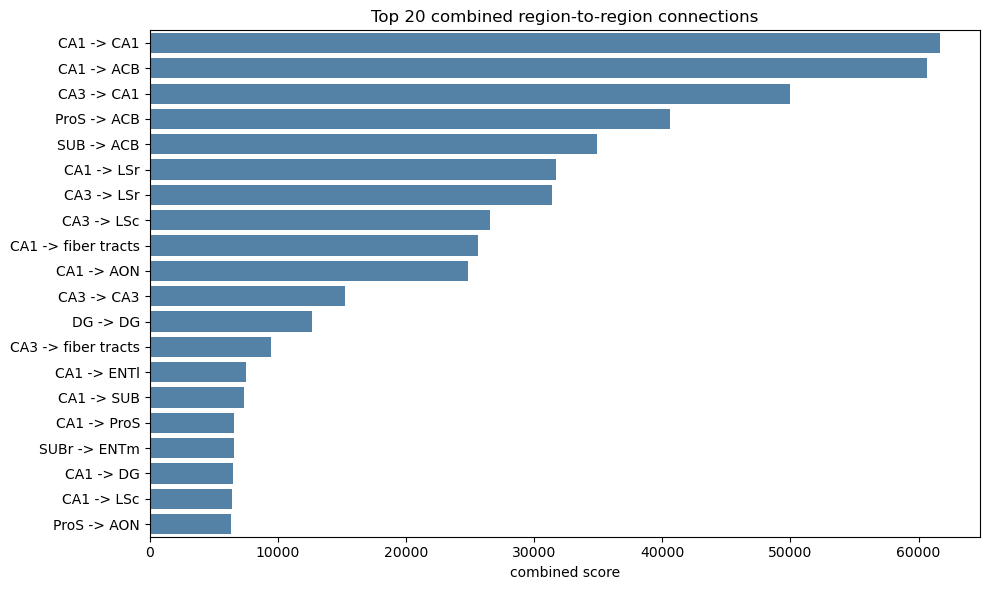

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

top_region = region_net_df.sort_values("score", ascending=False).head(20).copy()
top_region["edge"] = top_region["source_region"] + " -> " + top_region["target_region"]

plt.figure(figsize=(10,6))
sns.barplot(data=top_region, y="edge", x="score", color="steelblue")
plt.title("Top 20 combined region-to-region connections")
plt.xlabel("combined score")
plt.ylabel("")
plt.tight_layout()
plt.show()


画图，9k9k

In [35]:
import numpy as np
import pandas as pd

# =========================
# 1. 读取 region-level 结果
# =========================
region_net_df = pd.read_csv(
    "/home/zhangbei/data/ION_varicosity/jupyter_tutorial/save_results_full9026/analysing_results/9k9k/9k9k_combined_region_net_original.csv"
)

# =========================
# 2. 计算 mean_positive_score
# =========================
region_net_df["mean_positive_score"] = (
    region_net_df["score"] / region_net_df["pair_count"]
)

# =========================
# 3. 去掉不想解释的标签
# =========================
drop_labels = ["fiber tracts", "unknow"]

region_net_df = region_net_df[
    ~region_net_df["source_region"].isin(drop_labels)
    & ~region_net_df["target_region"].isin(drop_labels)
].copy()

# =========================
# 4. 按 mean score 阈值过滤
# 低于阈值的脑区对置为 0
# =========================
mean_score_threshold = 1.0

filtered_pair_count = (
    (region_net_df["mean_positive_score"] > 0)
    & (region_net_df["mean_positive_score"] < mean_score_threshold)
).sum()

kept_pair_count = (
    region_net_df["mean_positive_score"] >= mean_score_threshold
).sum()

print(f"mean score threshold: {mean_score_threshold}")
print(f"filtered region-pair count: {filtered_pair_count}")
print(f"kept region-pair count: {kept_pair_count}")

region_net_df.loc[
    region_net_df["mean_positive_score"] < mean_score_threshold,
    "mean_positive_score"
] = 0

# =========================
# 5. pivot 成 mean 矩阵
# =========================
region2region_mean_mat = (
    region_net_df.pivot(
        index="source_region",
        columns="target_region",
        values="mean_positive_score"
    )
    .fillna(0)
)

print(region2region_mean_mat.shape)
display(region2region_mean_mat.iloc[:5, :8])

# =========================
# 6. 保存中间结果
# =========================
region2region_mean_mat.to_csv(
    "/home/zhangbei/data/ION_varicosity/jupyter_tutorial/save_results_full9026/analysing_results/9k9k/9k9k_combined_region_net_mean_positive_matrix_original_1,0.csv"
)

region_net_df.to_csv(
    "/home/zhangbei/data/ION_varicosity/jupyter_tutorial/save_results_full9026/analysing_results/9k9k/9k9k_combined_region_net_mean_positive_longtable_original_1,0.csv",
    index=False
)


mean score threshold: 1.0
filtered region-pair count: 1
kept region-pair count: 48
(7, 7)


target_region,CA1,CA2,CA3,DG,ProS,SUB,SUBr
source_region,,,,,,,
CA1,3.226310,2.882746,2.647387,1.974265,2.493620,2.115229,1.492959
CA2,3.141620,3.562272,3.325723,1.429340,2.233042,1.315924,1.836168
CA3,2.490649,2.264340,2.932959,1.887632,1.993965,1.629054,1.202285
DG,1.796007,1.111052,1.345787,2.323058,1.767429,1.759155,1.968515
ProS,2.207529,0.000000,1.373189,1.370483,2.788465,2.226299,1.629850


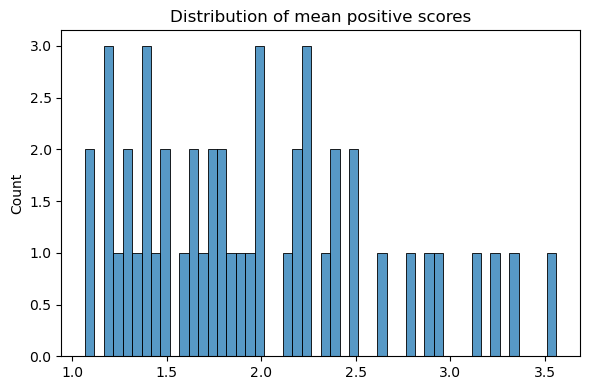

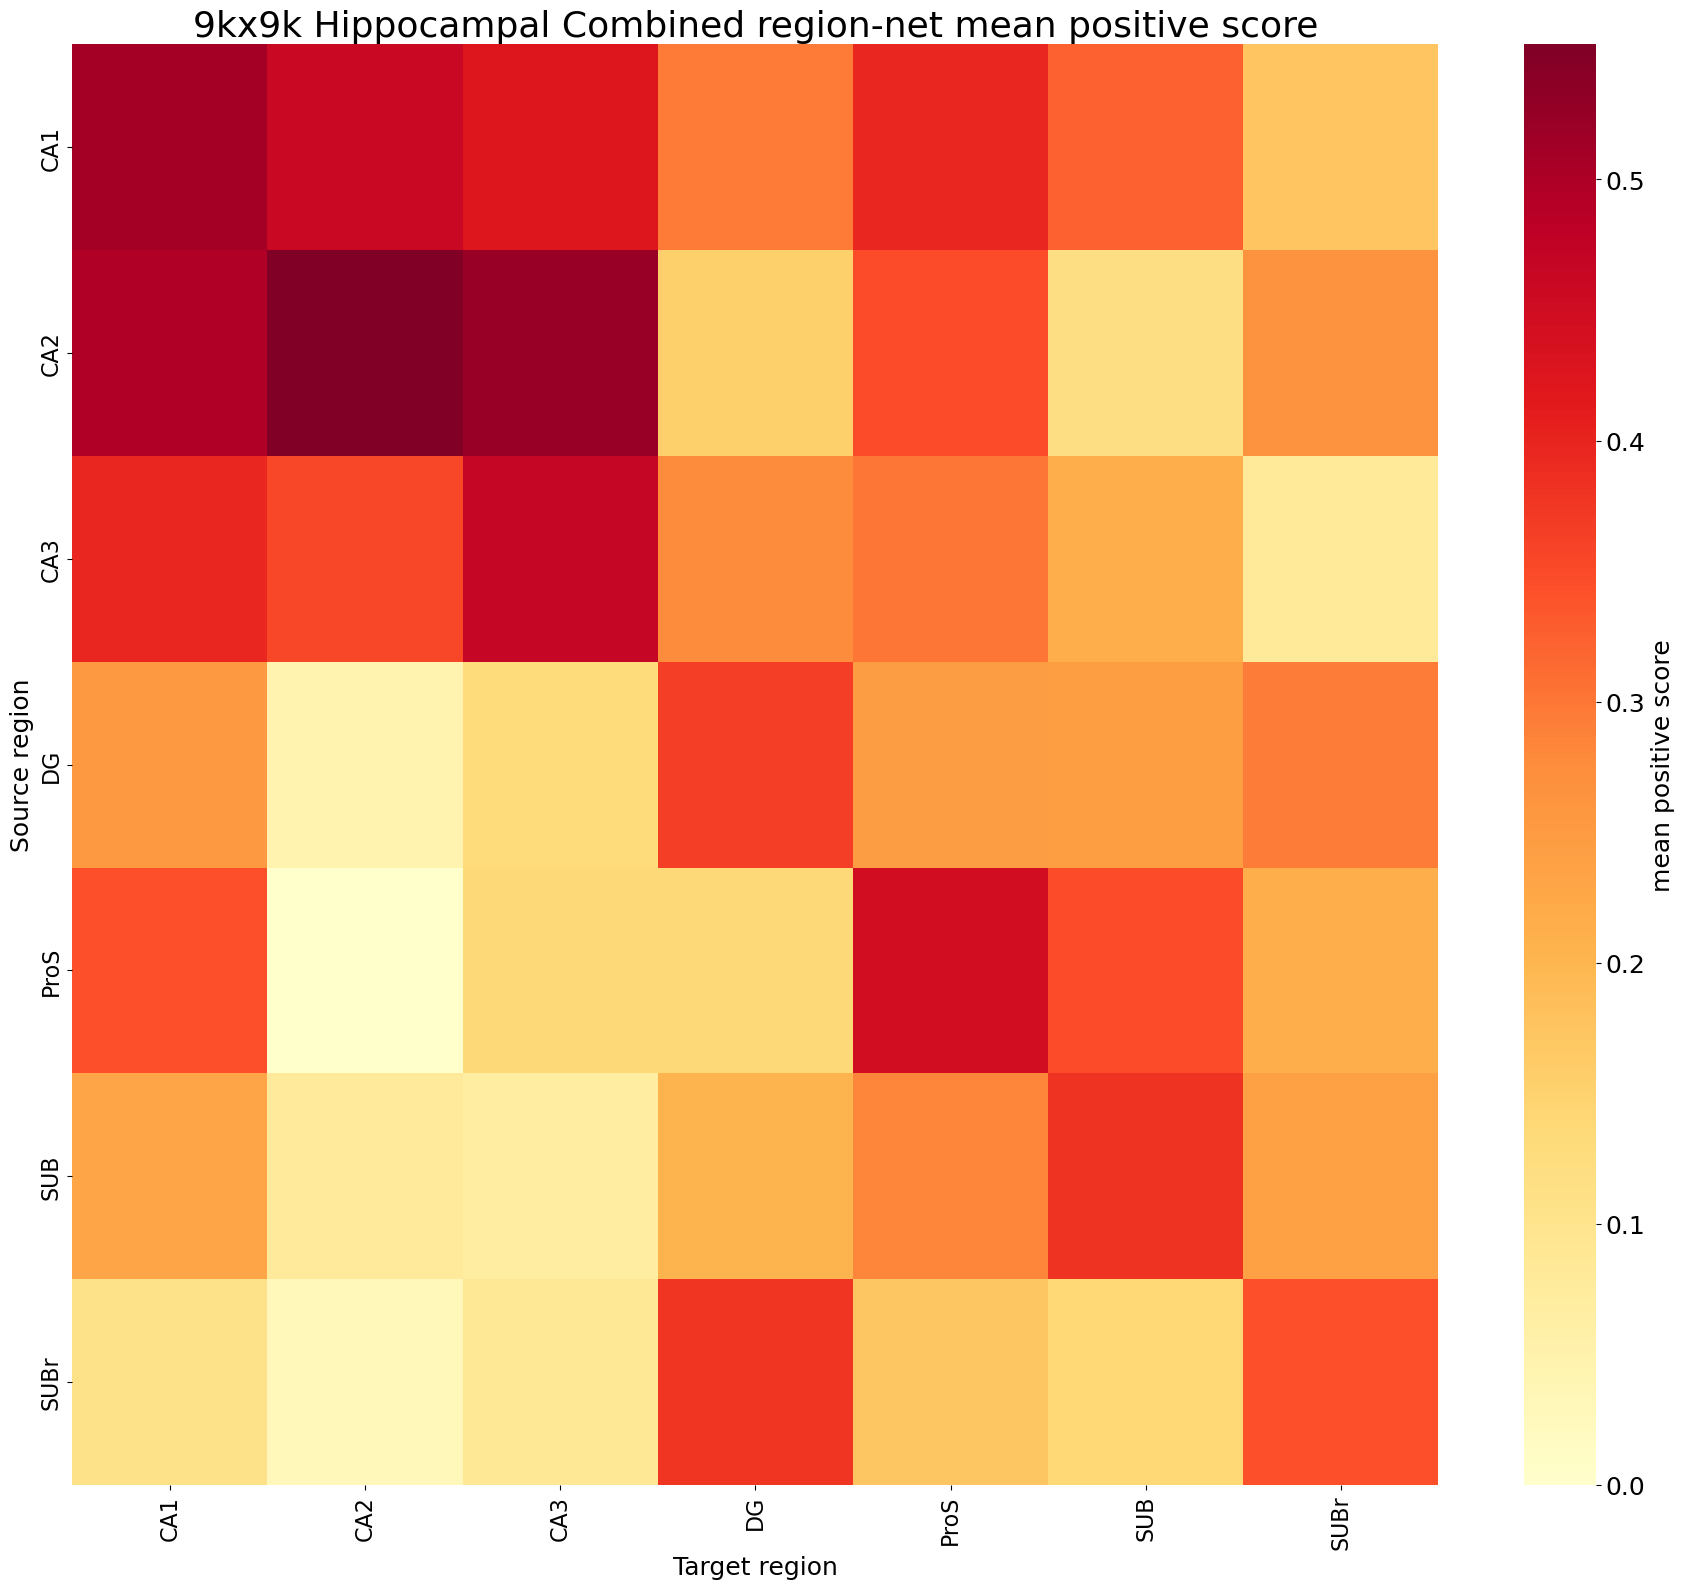

(7, 7)


In [36]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# =========================
# 1. 读取已经存好的 mean-score 结果
# =========================
region2region_mean_mat = pd.read_csv(
    "/home/zhangbei/data/ION_varicosity/jupyter_tutorial/save_results_full9026/analysing_results/9k9k/9k9k_combined_region_net_mean_positive_matrix_original.csv"
)


region2region_mean_mat = region_net_df.pivot(index="source_region", columns="target_region", values="mean_positive_score")
# 2. 先看非零值分布
used_mask = region2region_mean_mat.values > 0
values_list = region2region_mean_mat.values[used_mask]


# 3. 对非零值做 log10 变换
log_values =values_list

v = region2region_mean_mat.values.copy()
v[used_mask] = np.log10(log_values)

region2region_mean_scaled = pd.DataFrame(
    v,
    index=region2region_mean_mat.index,
    columns=region2region_mean_mat.columns
)



plt.figure(figsize=(6, 4))
sns.histplot(values_list, bins=50)
plt.title("Distribution of mean positive scores")
plt.tight_layout()
plt.show()

# 4. 热力图
plt.figure(figsize=(18, 16))
ax = sns.heatmap(
    region2region_mean_scaled,
    cmap="YlOrRd",
    vmin=0,
    cbar_kws={"label": "mean positive score"}
)

plt.title("9kx9k Hippocampal Combined region-net mean positive score", fontsize=26)
plt.xlabel("Target region", fontsize=18)
plt.ylabel("Source region", fontsize=18)

# 调整 colorbar 字体
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=18)        # 刻度字体
cbar.set_label("mean positive score", fontsize=18)  # colorbar 标题字体

plt.xticks(fontsize=16, rotation=90)
plt.yticks(fontsize=16)

plt.tight_layout()
plt.savefig(
    "/home/zhangbei/data/ION_varicosity/jupyter_tutorial/save_results_full9026/analysing_results/9k9k/9k9k_region2region_mean_heatmap_original.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(region2region_mean_mat.shape)

海马内部热力图

海马全脑热力图

(7, 177)


,AAA,ACAd,ACAv,ACB,ADP,AHN,AId,AIp
source_region,,,,,,,,
CA1,0.0,1.016433,1.469483,1.255384,0.000000,0.0,1.405529,1.479763
CA2,0.0,0.000000,0.000000,0.000000,0.000000,0.0,1.537645,0.000000
CA3,0.0,0.000000,1.370680,1.165521,0.000000,0.0,0.000000,0.000000
DG,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
ProS,0.0,0.000000,2.527387,1.415894,1.061759,0.0,1.112260,1.090556


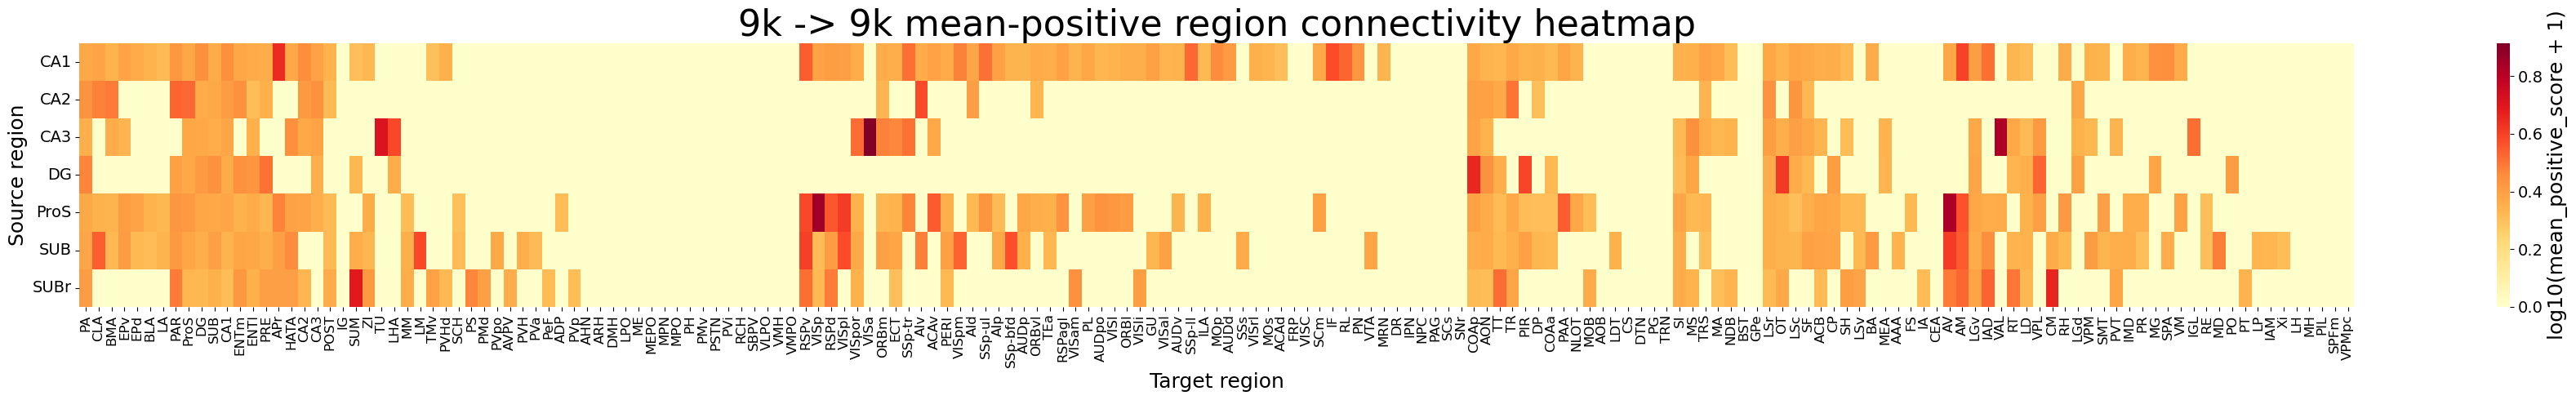

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json


def sort_targets_by_super_structure(
    df,
    map_path="/home/zhangbei/data/ION_varicosity/jupyter_tutorial/data_9026/super_region_map.json"
):
    with open(map_path, "r") as f:
        super_map = json.load(f)

    super_order = [f"CA{i}" for i in range(1, 14)]
    super_rank_map = {sid: i for i, sid in enumerate(super_order)}

    target_strength = df.sum(axis=0)

    target_sort_df = pd.DataFrame({
        "target_region": df.columns.astype(str)
    })

    target_sort_df["super_id"] = target_sort_df["target_region"].map(
        lambda x: super_map.get(x, {}).get("super_id", "ZZZ")
    )
    target_sort_df["super_rank"] = target_sort_df["super_id"].map(
        lambda x: super_rank_map.get(x, len(super_order))
    )
    target_sort_df["strength"] = target_sort_df["target_region"].map(target_strength)

    target_order = (
        target_sort_df
        .sort_values(
            ["super_rank", "strength", "target_region"],
            ascending=[True, False, True]
        )["target_region"]
        .tolist()
    )

    return df.loc[:, target_order], target_sort_df


# =========================
# 1. 直接读取 mean score 中间矩阵
# =========================
region_mat = pd.read_csv(
    "/home/zhangbei/data/ION_varicosity/jupyter_tutorial/save_results_full9026/analysing_results/9k9k/9k9k_combined_region_net_mean_positive_matrix_original_1,0.csv",
    index_col=0
)

print(region_mat.shape)
display(region_mat.iloc[:5, :8])

# =========================
# 2. 按 target 总强度排序
# =========================
region_mat, target_sort_df = sort_targets_by_super_structure(region_mat)

# =========================
# 3. 画热力图
# =========================
plot_mat = np.log10(region_mat + 1)

plt.figure(figsize=(36, 5))
ax = sns.heatmap(
    plot_mat,
    cmap="YlOrRd",
    vmin=0,
    cbar_kws={"label": "log10(mean_positive_score + 1)"}
)

ax.set_title("9k -> 9k mean-positive region connectivity heatmap", fontsize=32)
ax.set_xlabel("Target region", fontsize=18)
ax.set_ylabel("Source region", fontsize=18)

step = 1
xticks = np.arange(plot_mat.shape[1]) + 0.5
ax.set_xticks(xticks[::step])
ax.set_xticklabels(plot_mat.columns[::step], rotation=90, fontsize=12)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=14)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)
cbar.set_label("log10(mean_positive_score + 1)", fontsize=18)

plt.tight_layout()
plt.savefig(
    "/home/zhangbei/data/ION_varicosity/jupyter_tutorial/save_results_full9026/analysing_results/9k9k/9k9k_combined_region_net_mean_positive_heatmap_original_1,0.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


(7, 177)


,AAA,ACAd,ACAv,ACB,ADP,AHN,AId,AIp
source_region,,,,,,,,
CA1,0.0,1.016433,1.469483,1.255384,0.000000,0.0,1.405529,1.479763
CA2,0.0,0.000000,0.000000,0.000000,0.000000,0.0,1.537645,0.000000
CA3,0.0,0.000000,1.370680,1.165521,0.000000,0.0,0.000000,0.000000
DG,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000
ProS,0.0,0.000000,2.527387,1.415894,1.061759,0.0,1.112260,1.090556


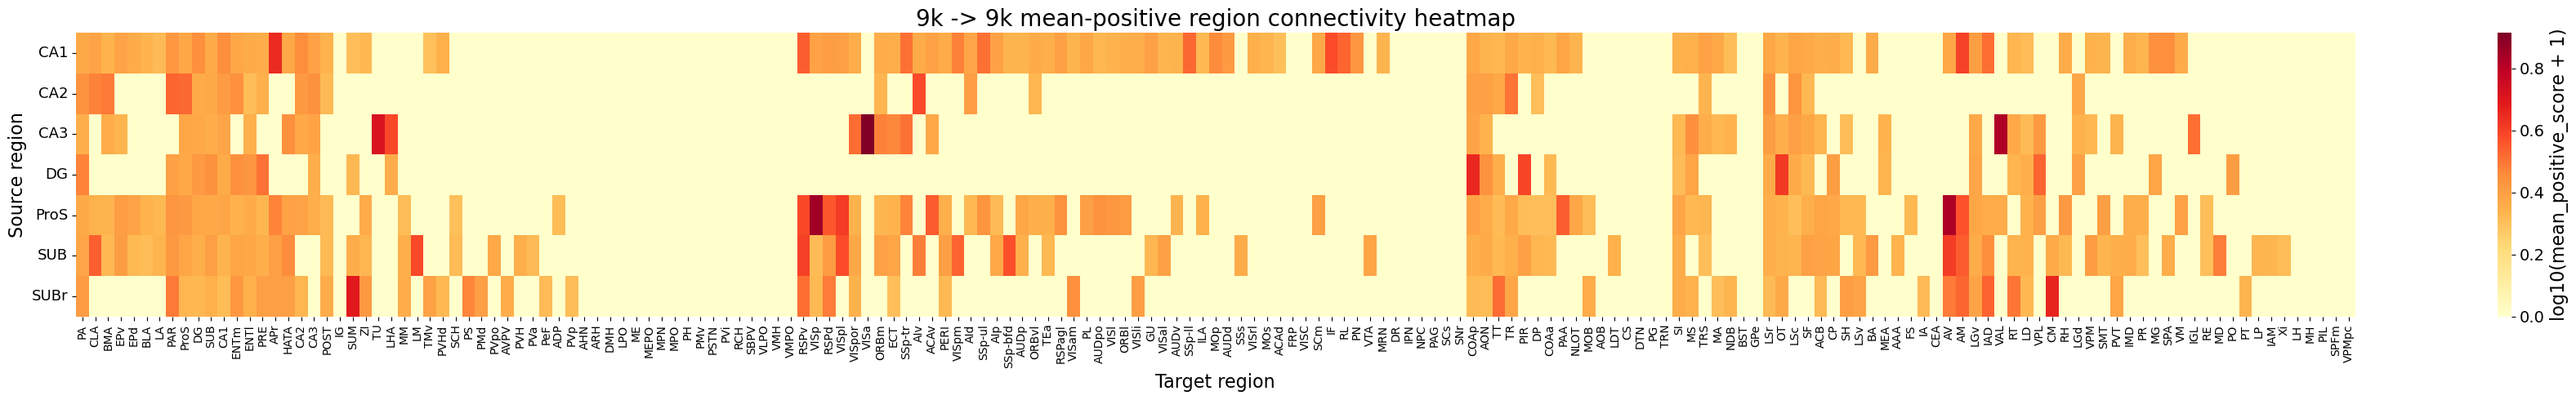

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

def sort_targets_by_super_structure(
    df,
    map_path="/home/zhangbei/data/ION_varicosity/jupyter_tutorial/data_9026/super_region_map.json"
):
    with open(map_path, "r") as f:
        super_map = json.load(f)

    super_order = [f"CA{i}" for i in range(1, 14)]
    super_rank_map = {sid: i for i, sid in enumerate(super_order)}

    target_strength = df.sum(axis=0)

    target_sort_df = pd.DataFrame({
        "target_region": df.columns.astype(str)
    })
    target_sort_df["super_id"] = target_sort_df["target_region"].map(
        lambda x: super_map.get(x, {}).get("super_id", "ZZZ")
    )
    target_sort_df["super_rank"] = target_sort_df["super_id"].map(
        lambda x: super_rank_map.get(x, len(super_order))
    )
    target_sort_df["strength"] = target_sort_df["target_region"].map(target_strength)

    target_order = (
        target_sort_df
        .sort_values(
            ["super_rank", "strength", "target_region"],
            ascending=[True, False, True]
        )["target_region"]
        .tolist()
    )

    return df.loc[:, target_order], target_sort_df

# =========================
# 1. 读取已经存好的 region-level 结果
# =========================
region_net_df = pd.read_csv(
    "/home/zhangbei/data/ION_varicosity/jupyter_tutorial/save_results_full9026/analysing_results/9k9k/9k9k_combined_region_net_original.csv"
)

# =========================
# 2. 从 sum 和 pair_count 直接得到 mean_positive_score
# =========================
region_net_df["mean_positive_score"] = region_net_df["score"] / region_net_df["pair_count"]

# =========================
# 3. 去掉不想解释的标签
# =========================
drop_labels = ["fiber tracts", "unknow"]

region_net_df = region_net_df[
    ~region_net_df["source_region"].isin(drop_labels) &
    ~region_net_df["target_region"].isin(drop_labels)
].copy()

# =========================
# 4. pivot
# =========================
region_mat = (
    region_net_df.pivot(
        index="source_region",
        columns="target_region",
        values="mean_positive_score"
    )
    .fillna(0)
)

print(region_mat.shape)
display(region_mat.iloc[:5, :8])

# =========================
# 5. 按 target 总强度排序
# =========================
region_mat, target_sort_df = sort_targets_by_super_structure(region_mat)

# =========================
# 6. 保存 mean 矩阵
# =========================
region_mat.to_csv(
    "/home/zhangbei/data/ION_varicosity/jupyter_tutorial/save_results_full9026/analysing_results/9k9k/9k9k_combined_region_net_mean_positive_matrix_original.csv"
)

# 也顺手存 long table
region_net_df.to_csv(
    "/home/zhangbei/data/ION_varicosity/jupyter_tutorial/save_results_full9026/analysing_results/9k9k/9k9k_combined_region_net_mean_positive_longtable_original.csv",
    index=False
)

# =========================
# 7. 画热力图
# =========================
plot_mat = np.log10(region_mat + 1)

plt.figure(figsize=(36, 5))
ax = sns.heatmap(
    plot_mat,
    cmap="YlOrRd",
    vmin=0,
    cbar_kws={"label": "log10(mean_positive_score + 1)"}
)

ax.set_title("9k -> 15w mean-positive region connectivity heatmap", fontsize=20)
ax.set_xlabel("Target region", fontsize=16)
ax.set_ylabel("Source region", fontsize=16)

step = 6
xticks = np.arange(plot_mat.shape[1]) + 0.5
ax.set_xticks(xticks[::step])
ax.set_xticklabels(plot_mat.columns[::step], rotation=90, fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=13)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)
cbar.set_label("log10(mean_positive_score + 1)", fontsize=16)

plt.tight_layout()
plt.savefig(
    "/home/zhangbei/data/ION_varicosity/jupyter_tutorial/save_results_full9026/analysing_results/9k9k/9k9k_combined_region_net_mean_positive_heatmap_original.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


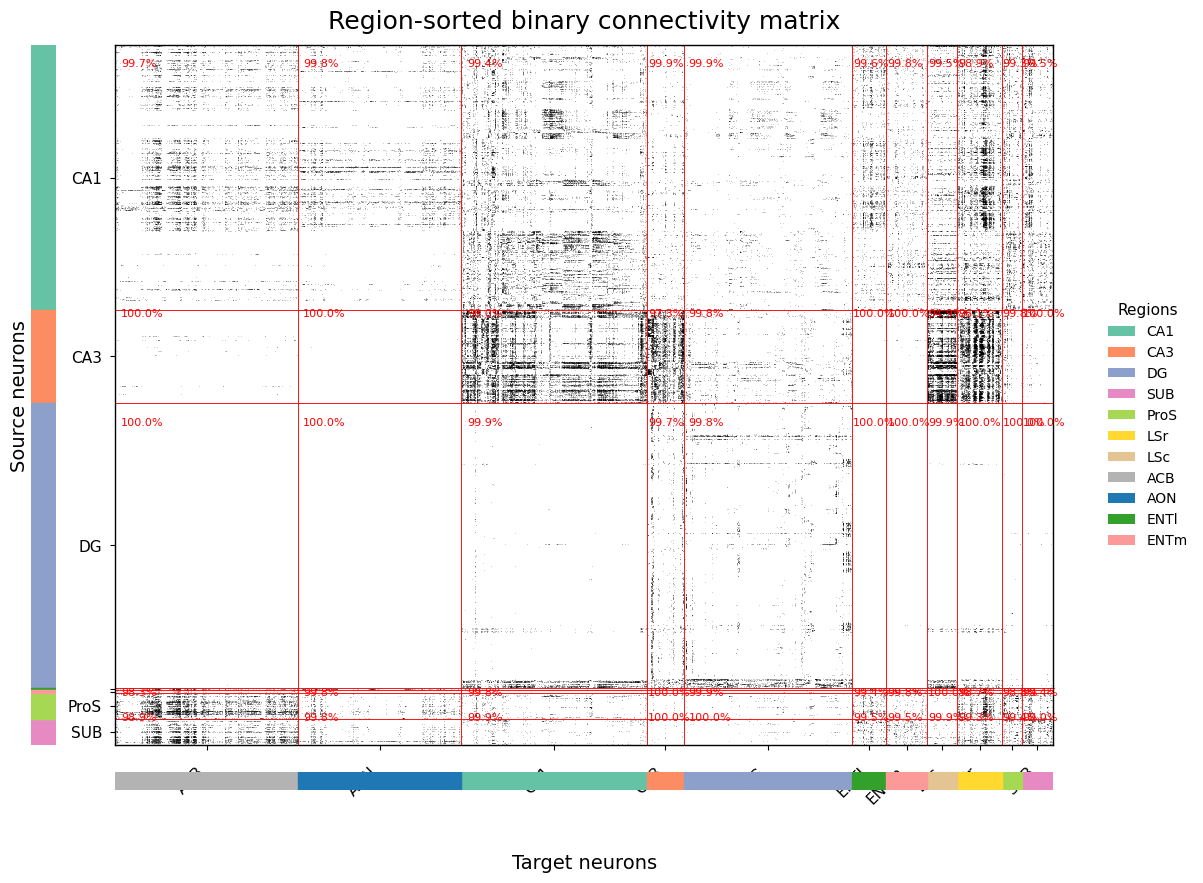

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch

# =========================
# 1. 输入文件
# =========================
score_path = "/home/zhangbei/data/ION_varicosity/jupyter_tutorial/save_results_full6554/single_cell_connections/arbor_results_pac_6kx15w/arbor_connectivity_sparse.parquet"
# bouton 的话改成：
# score_path = "/home/zhangbei/data/ION_varicosity/jupyter_tutorial/save_results_full6554/single_cell_connections/bouton_results_pb_6kx15w/bouton_connectivity_sparse.parquet"

src_meta_path = "/home/zhangbei/data/ION_varicosity/jupyter_tutorial/data_6554/6554_cells_metadata.csv"
tar_meta_path = "/home/zhangbei/data/ION_varicosity/jupyter_tutorial/data_6554/15w_cells_metadata.csv"

save_path = "/home/zhangbei/data/ION_varicosity/jupyter_tutorial/analysing_results/region_sorted_binary_matrix_clean.png"

# =========================
# 2. 读数据
# =========================
df = pd.read_parquet(score_path)
src_meta = pd.read_csv(src_meta_path, index_col=0)
tar_meta = pd.read_csv(tar_meta_path, index_col=0)

df["source_region"] = df["source_cell"].map(src_meta["region"].to_dict())
df["target_region"] = df["target_cell"].map(tar_meta["region"].to_dict())

df = df.dropna(subset=["source_region", "target_region"]).copy()
df["conn"] = 1

# =========================
# 3. 选择主要脑区
# =========================
keep_regions = [
    "CA1", "CA3", "DG", "SUB", "ProS",
    "LSr", "LSc", "ACB", "AON", "ENTl", "ENTm"
]

df = df[
    df["source_region"].isin(keep_regions) &
    df["target_region"].isin(keep_regions)
].copy()

# =========================
# 4. 建立 source / target 排序索引
# =========================
src_order_df = (
    df[["source_cell", "source_region"]]
    .drop_duplicates()
    .sort_values(["source_region", "source_cell"])
    .reset_index(drop=True)
)
src_order_df["row_idx"] = np.arange(len(src_order_df))

tar_order_df = (
    df[["target_cell", "target_region"]]
    .drop_duplicates()
    .sort_values(["target_region", "target_cell"])
    .reset_index(drop=True)
)
tar_order_df["col_idx"] = np.arange(len(tar_order_df))
ß
df = df.merge(src_order_df[["source_cell", "row_idx"]], on="source_cell", how="left")
df = df.merge(tar_order_df[["target_cell", "col_idx"]], on="target_cell", how="left")

# =========================
# 5. 脑区 block 信息
# =========================
src_blocks = (
    src_order_df.groupby("source_region")
    .agg(start=("row_idx", "min"), end=("row_idx", "max"), n=("row_idx", "size"))
    .reset_index()
)

tar_blocks = (
    tar_order_df.groupby("target_region")
    .agg(start=("col_idx", "min"), end=("col_idx", "max"), n=("col_idx", "size"))
    .reset_index()
)

# 固定脑区顺序
src_blocks["source_region"] = pd.Categorical(src_blocks["source_region"], categories=keep_regions, ordered=True)
tar_blocks["target_region"] = pd.Categorical(tar_blocks["target_region"], categories=keep_regions, ordered=True)
src_blocks = src_blocks.sort_values("source_region").reset_index(drop=True)
tar_blocks = tar_blocks.sort_values("target_region").reset_index(drop=True)

# =========================
# 6. 脑区颜色
# =========================
region_colors = {
    "CA1": "#66c2a5",
    "CA3": "#fc8d62",
    "DG": "#8da0cb",
    "SUB": "#e78ac3",
    "ProS": "#a6d854",
    "LSr": "#ffd92f",
    "LSc": "#e5c494",
    "ACB": "#b3b3b3",
    "AON": "#1f78b4",
    "ENTl": "#33a02c",
    "ENTm": "#fb9a99",
}

# =========================
# 7. 标签显示阈值
# 小于阈值的脑区不在主轴显示文字，避免重叠
# =========================
min_src_label_cells = 120
min_tar_label_cells = 250

src_tick_pos = src_blocks["start"] + src_blocks["n"] / 2
src_tick_labels = [
    r["source_region"] if r["n"] >= min_src_label_cells else ""
    for _, r in src_blocks.iterrows()
]

tar_tick_pos = tar_blocks["start"] + tar_blocks["n"] / 2
tar_tick_labels = [
    r["target_region"] if r["n"] >= min_tar_label_cells else ""
    for _, r in tar_blocks.iterrows()
]

# =========================
# 8. 作图
# =========================
fig = plt.figure(figsize=(14, 10))

# 主矩阵
ax = fig.add_axes([0.18, 0.18, 0.67, 0.70])

# 左侧颜色条
ax_left = fig.add_axes([0.12, 0.18, 0.018, 0.70])

# 下侧颜色条
ax_bottom = fig.add_axes([0.18, 0.135, 0.67, 0.018])

# 主矩阵散点
ax.scatter(
    df["col_idx"],
    df["row_idx"],
    s=0.08,
    c="black",
    alpha=0.8,
    linewidths=0
)

ax.set_xlim(-1, len(tar_order_df))
ax.set_ylim(len(src_order_df), -1)

ax.set_title("Region-sorted binary connectivity matrix", fontsize=18, pad=12)
ax.set_xlabel("Target neurons", fontsize=14, labelpad=34)
ax.set_ylabel("Source neurons", fontsize=14, labelpad=28)

# y轴标签
ax.set_yticks(src_tick_pos)
ax.set_yticklabels(src_tick_labels, fontsize=11)
ax.tick_params(axis="y", pad=6)

# x轴标签
ax.set_xticks(tar_tick_pos)
ax.set_xticklabels(tar_tick_labels, rotation=45, ha="right", fontsize=11)
ax.tick_params(axis="x", pad=10)

for spine in ax.spines.values():
    spine.set_linewidth(1.0)

ax.set_facecolor("white")

# 左侧 source 脑区颜色条
for _, r in src_blocks.iterrows():
    ax_left.add_patch(Rectangle(
        (0, r["start"]),
        1,
        r["n"],
        color=region_colors.get(r["source_region"], "lightgray")
    ))
ax_left.set_xlim(0, 1)
ax_left.set_ylim(len(src_order_df), 0)
ax_left.axis("off")

# 下侧 target 脑区颜色条
for _, r in tar_blocks.iterrows():
    ax_bottom.add_patch(Rectangle(
        (r["start"], 0),
        r["n"],
        1,
        color=region_colors.get(r["target_region"], "lightgray")
    ))
ax_bottom.set_xlim(0, len(tar_order_df))
ax_bottom.set_ylim(0, 1)
ax_bottom.axis("off")

# =========================
# 9. 红框和 sparsity
# =========================
for _, sr in src_blocks.iterrows():
    for _, tr in tar_blocks.iterrows():
        block_df = df[
            (df["source_region"] == sr["source_region"]) &
            (df["target_region"] == tr["target_region"])
        ]

        total_possible = sr["n"] * tr["n"]
        n_conn = len(block_df)

        if total_possible == 0:
            continue

        sparsity = 100 * (1 - n_conn / total_possible)

        ax.add_patch(Rectangle(
            (tr["start"], sr["start"]),
            tr["n"],
            sr["n"],
            fill=False,
            edgecolor="red",
            linewidth=0.6,
            alpha=0.8
        ))

        # 只给较大的 block 标数字
        if sr["n"] > 25 and tr["n"] > 25:
            ax.text(
                tr["start"] + tr["n"] * 0.03,
                sr["start"] + sr["n"] * 0.08,
                f"{sparsity:.1f}%",
                color="red",
                fontsize=8
            )

# =========================
# 10. 图例：所有脑区名称都放这里，避免轴上挤
# =========================
legend_handles = [
    Patch(facecolor=region_colors[r], edgecolor="none", label=r)
    for r in keep_regions if r in region_colors
]

fig.legend(
    handles=legend_handles,
    loc="center left",
    bbox_to_anchor=(0.88, 0.5),
    frameon=False,
    title="Regions",
    fontsize=10,
    title_fontsize=11
)

# =========================
# 11. 保存 + 显示
# =========================

plt.show()
